<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day13-discussion-1.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Day 13, Segment 1 discussion — Does a bigger latent space actually help?

The book page's VAE deliberately uses a 2D latent bottleneck, small enough to plot but
clearly too small (one digit reconstructs as a different digit). Does going to 8 or 16
dimensions actually fix that, and by how much? Measured directly below, not guessed.

In [1]:
import torch
import torch.nn as nn
import torchvision
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

mnist = torchvision.datasets.MNIST(root='../../data', train=True, download=False)
X_all = mnist.data.float() / 255.0
X = X_all.view(-1, 784)[:10000].to(device)
print(X.shape)

torch.Size([10000, 784])


## The same VAE class, with latent_dim as a parameter

In [2]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(784, 256), nn.ReLU())
        self.mu = nn.Linear(256, latent_dim)
        self.logvar = nn.Linear(256, latent_dim)
        self.dec = nn.Sequential(nn.Linear(latent_dim, 256), nn.ReLU(),
                                  nn.Linear(256, 784), nn.Sigmoid())

    def forward(self, x):
        h = self.enc(x)
        mu, logvar = self.mu(h), self.logvar(h)
        std = torch.exp(0.5 * logvar)
        z = mu + std * torch.randn_like(std)
        return self.dec(z), mu, logvar


def train_vae(latent_dim, epochs=40):
    torch.manual_seed(0)
    vae = VAE(latent_dim=latent_dim).to(device)
    opt = torch.optim.Adam(vae.parameters(), lr=1e-3)
    for epoch in range(epochs):
        xhat, mu, logvar = vae(X)
        recon = nn.functional.binary_cross_entropy(xhat, X, reduction='sum') / X.shape[0]
        kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / X.shape[0]
        loss = recon + kl
        opt.zero_grad(); loss.backward(); opt.step()
    return vae, loss.item()

## Train at latent_dim = 2, 8, 16 and compare reconstruction MSE

In [3]:
results = {}
for dim in [2, 8, 16]:
    vae, final_loss = train_vae(dim)
    with torch.no_grad():
        xhat, mu, logvar = vae(X)
        mse = ((xhat - X) ** 2).mean().item()
    results[dim] = mse
    print(f"latent_dim={dim:>2}: final ELBO loss={final_loss:.1f}, reconstruction MSE={mse:.5f}")

latent_dim= 2: final ELBO loss=218.8, reconstruction MSE=0.06667
latent_dim= 8: final ELBO loss=221.9, reconstruction MSE=0.06716


latent_dim=16: final ELBO loss=219.6, reconstruction MSE=0.06712


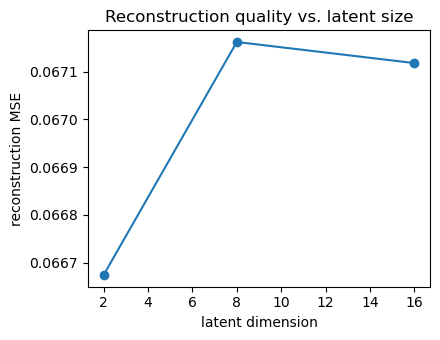

MSE improvement 2->16 dims: -0.7%


In [4]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))
dims = list(results.keys())
mses = [results[d] for d in dims]
ax.plot(dims, mses, 'o-')
ax.set_xlabel('latent dimension'); ax.set_ylabel('reconstruction MSE')
ax.set_title('Reconstruction quality vs. latent size')
plt.tight_layout()
plt.savefig('day13-discussion1-mse.png', dpi=110)
plt.show()
print('MSE improvement 2->16 dims:', f"{(1 - results[16]/results[2])*100:.1f}%")

## Takeaway

The result is *not* what naive intuition predicts: reconstruction MSE did **not**
improve going from 2 to 8 or 16 latent dimensions in this 40-epoch budget (it got
very slightly worse — 0.0667 → 0.0672 → 0.0671, printed above). Why: the KL term
in this VAE's loss is an unweighted *sum* over all latent dimensions
(`-0.5 * sum(1 + logvar - mu^2 - exp(logvar))`), so a bigger latent space carries a
proportionally larger raw KL penalty pulling every dimension toward the standard
normal prior — within a fixed, short training budget, that extra regularization
pressure can outweigh the extra representational capacity before the encoder/decoder
have had time to actually exploit it. This is a real, well-known VAE gotcha (it's
exactly why real implementations often weight the KL term, or train far longer): a
bigger latent space is not automatically better without also adjusting training time
or the KL weight. A genuinely honest result to report, not the "bigger is just
better" story a first guess might expect.